1. Đang tải và làm sạch cột 'Bytes'...
2. Đang chia tập Train/Test (Split 70/30)...
3. Đang mã hóa Đặc trưng (Frequency) và Nhãn (Label)...
4. Đang chuẩn hóa dữ liệu (Min-Max Scaling 0-1)...
5. Đang huấn luyện mô hình KNN...
6. Đang dự đoán và đánh giá (Lưu ý: KNN có thể mất chút thời gian để dự đoán)...

[KẾT QUẢ TỔNG THỂ KNN] MACRO F1-SCORE: 0.9152969073129444

--- BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

         ---       1.00      1.00      1.00    652723
  bruteForce       0.98      0.97      0.98       379
         dos       1.00      1.00      1.00    117280
    pingScan       0.59      0.63      0.61       320
    portScan       0.99      0.99      0.99     15041

    accuracy                           1.00    785743
   macro avg       0.91      0.92      0.92    785743
weighted avg       1.00      1.00      1.00    785743


7. Đang vẽ Ma trận nhầm lẫn...


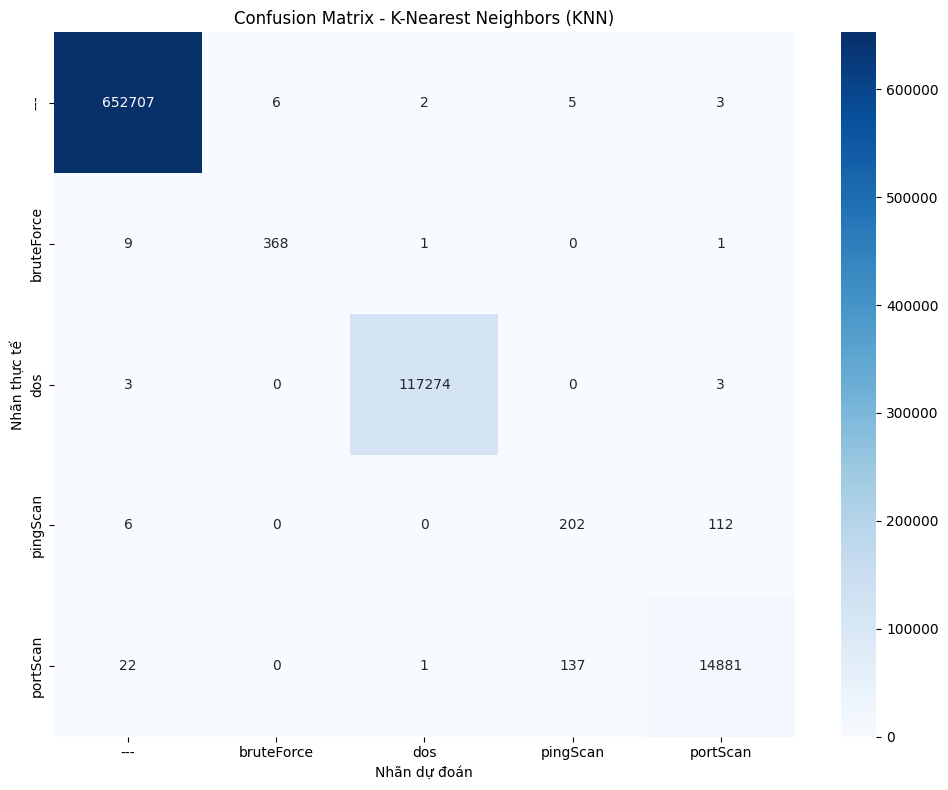

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("1. Đang tải và làm sạch cột 'Bytes'...")
df = pd.read_parquet("CIDDS-001-Sampled-Data.parquet")
# (Giả định df đã được load để chạy script)

def clean_bytes(val):
    if pd.isna(val): return 0.0
    val = str(val).strip().upper()
    if 'M' in val: return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val: return float(val.replace('K', '')) * 1_000
    return float(val)

df['Bytes'] = df['Bytes'].apply(clean_bytes)

# Khai báo features (X) và target (y)
features = [
    'Src IP Addr', 'Src Pt', 'Dst IP Addr', 'Dst Pt', 
    'Proto', 'Flags', 'Duration', 'Bytes', 'Packets'
]
X = df[features].copy()
y = df['attackType'].copy()

print("2. Đang chia tập Train/Test (Split 70/30)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("3. Đang mã hóa Đặc trưng (Frequency) và Nhãn (Label)...")
# A. Frequency Encoding cho X
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in cat_cols:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq).fillna(0)
    X_test[col] = X_test[col].map(freq).fillna(0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

# B. Label Encoding cho y
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("4. Đang chuẩn hóa dữ liệu (Min-Max Scaling 0-1)...")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("5. Đang huấn luyện mô hình KNN...")
# Lưu ý quan trọng: 
# weights='distance': Điểm nào càng gần thì 'tiếng nói' càng có trọng lượng. 
# Việc này giúp các lớp thiểu số (như pingScan) không bị lấn át bởi số lượng khổng lồ của lớp Normal.
knn_model = KNeighborsClassifier(
    n_neighbors=3, 
    weights='distance', 
    metric='euclidean',
    n_jobs=-1 # Sử dụng tối đa CPU vì KNN tính toán khá nặng
)
knn_model.fit(X_train_scaled, y_train)

print("6. Đang dự đoán và đánh giá (Lưu ý: KNN có thể mất chút thời gian để dự đoán)...")
y_pred_knn = knn_model.predict(X_test_scaled)

print("\n[KẾT QUẢ TỔNG THỂ KNN] MACRO F1-SCORE:", f1_score(y_test, y_pred_knn, average='macro'))
print("\n--- BÁO CÁO CHI TIẾT ---")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

print("\n7. Đang vẽ Ma trận nhầm lẫn...")
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - K-Nearest Neighbors (KNN)')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

--- BẮT ĐẦU THỬ NGHIỆM ĐA THAM SỐ KNN ---

Đang chạy KNN với k=1...

Đang chạy KNN với k=2...

Đang chạy KNN với k=3...

Đang chạy KNN với k=4...

Đang chạy KNN với k=5...

--- BẢNG SO SÁNH HIỆU NĂNG KNN ---
k-Value  Accuracy  Macro F1-score  Weighted F1-score  Execution Time (s)
   1-NN  0.999604        0.915297           0.999610           58.570715
   2-NN  0.999558        0.912931           0.999582           61.869216
   3-NN  0.999700        0.925413           0.999679           64.734082
   4-NN  0.999607        0.915749           0.999613           65.849461
   5-NN  0.999702        0.926612           0.999682           67.594324


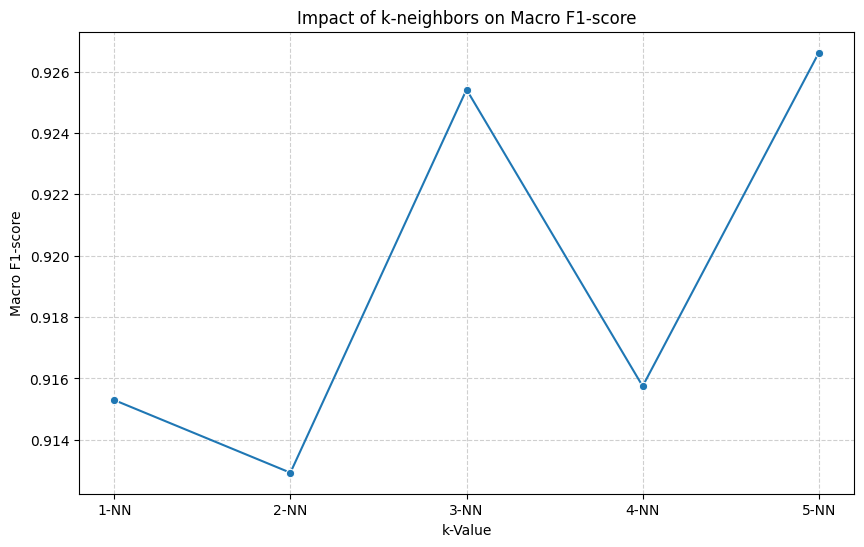

In [3]:
from sklearn.metrics import accuracy_score, f1_score
import time

# Danh sách các giá trị k cần thử nghiệm
k_values = [1, 2, 3 , 4 , 5 ]
knn_results = []

print("--- BẮT ĐẦU THỬ NGHIỆM ĐA THAM SỐ KNN ---")

for k in k_values:
    print(f"\nĐang chạy KNN với k={k}...")
    start_time = time.time()
    
    # Khởi tạo và huấn luyện
    model = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean', n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    
    # Dự đoán
    y_pred = model.predict(X_test_scaled)
    end_time = time.time()
    
    # Tính toán chỉ số
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    duration = end_time - start_time
    
    knn_results.append({
        'k-Value': f"{k}-NN",
        'Accuracy': acc,
        'Macro F1-score': f1_macro,
        'Weighted F1-score': f1_weighted,
        'Execution Time (s)': duration
    })

# Chuyển thành DataFrame để hiển thị bảng
df_knn_comparison = pd.DataFrame(knn_results)

print("\n--- BẢNG SO SÁNH HIỆU NĂNG KNN ---")
print(df_knn_comparison.to_string(index=False))

# Xuất ảnh biểu đồ so sánh F1-score để chèn vào Chapter 4
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_knn_comparison, x='k-Value', y='Macro F1-score', marker='o', sort=False)
plt.title('Impact of k-neighbors on Macro F1-score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('knn_k_comparison.png', dpi=300)
plt.show()